In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.DataFrame({
    'X':[1400,1600,1700,1875,1100,1550,2350,2450,1425,1700],
    'Y':[245,312,279,308,199,219,405,324,319,255]
})

df

,X,Y
0,1400,245
1,1600,312
2,1700,279
3,1875,308
4,1100,199
5,1550,219
6,2350,405
7,2450,324
8,1425,319
9,1700,255


<Axes: xlabel='X', ylabel='Y'>

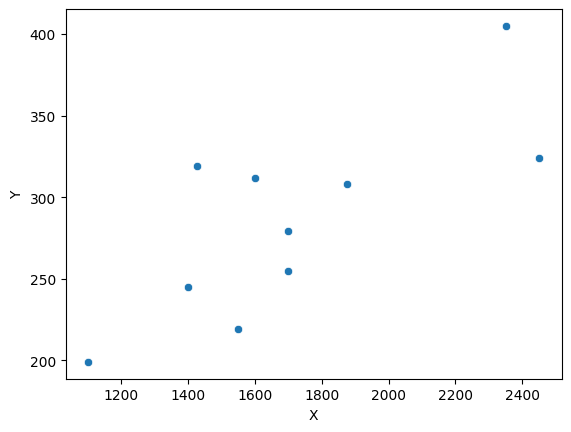

In [3]:
import seaborn as sns

sns.scatterplot(data=df, x='X', y='Y')

In [4]:
# Scaling features (required for Neural Networks)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(df[['X']])
y_scaled = scaler_y.fit_transform(df[['Y']])

model = Sequential([
    Dense(8, input_shape=[1]),
    Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mean_squared_error')
# MSE tells how much the wrong (error) is.

print("Training Neural Network...")
model.fit(X_scaled, y_scaled, epochs=500, verbose=0)
print("Training completed.")

/Users/sdsys/Files/acme/14. Regression and Classification using NN/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Neural Network...
Training completed.


In [5]:
test_input = scaler_X.transform([[1800]])
predicted_house_price_scaled = model.predict(test_input)
predicted_house_price = scaler_y.inverse_transform(predicted_house_price_scaled)
print(predicted_house_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[295.83026]]


/Users/sdsys/Files/acme/14. Regression and Classification using NN/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


<Axes: xlabel='X', ylabel='Y'>

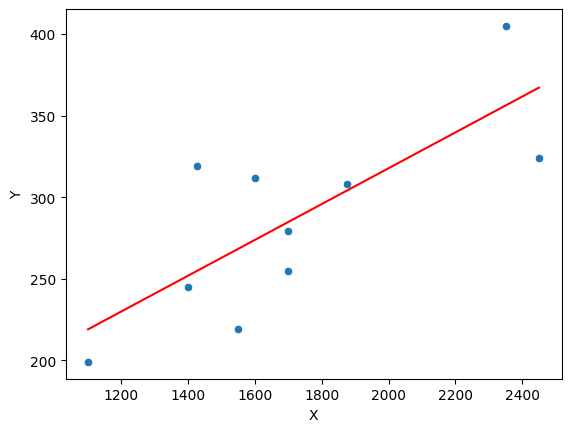

In [6]:
y_all_predicted_scaled = model.predict(X_scaled)
y_all_predicted = scaler_y.inverse_transform(y_all_predicted_scaled)

sns.scatterplot(data=df,x='X',y='Y')
sns.lineplot(x=df['X'],y=y_all_predicted.flatten(),color='red')

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error
r2 = r2_score(df['Y'], y_all_predicted)
mae = mean_absolute_error(df['Y'], y_all_predicted)

print(f"r2 score is {r2}")
print(f"MAE score is {mae}")

r2 score is 0.5808173418045044
MAE score is 31.03811264038086
